# Week 3 | Cleaning sprint

**Objective:** explain, implement and audit cleaning. The baseline removes exact duplicates,
repairs two damaged labels, fills numeric nulls with medians and retains flagged observations.
Alternative treatments are compared instead of selecting the one with the most dramatic findings.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Works when opened from the notebook folder, DSV_PROJECT, or repository root.
ROOT = next((p if (p/'Source_Code'/'attrition_lab.py').exists() else p/'DSV_PROJECT'
             for p in [Path.cwd(), *Path.cwd().parents]
             if (p/'Source_Code'/'attrition_lab.py').exists()
             or (p/'DSV_PROJECT'/'Source_Code'/'attrition_lab.py').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Open this notebook inside the DSV_PROJECT workspace.')
sys.path.insert(0, str(ROOT/'Source_Code'))
from attrition_lab import (load_raw, clean_data, quality_report, outlier_report,
                          rate_table, compare, evidence_tables, scenarios,
                          build_artifacts, NUMERIC, MISSING, ORDERS, CONTRASTS)
raw = load_raw()
sns.set_theme(style='whitegrid', palette=['#176B87','#DA7652','#71AFA0','#A18CB8'])
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.titleweight':'bold', 'axes.titlesize':13, 'font.size':10})
FIGURES = ROOT/'Reports'/'Figures'
FIGURES.mkdir(parents=True, exist_ok=True)
def finish(name):
    plt.tight_layout()
    plt.savefig(FIGURES/f'{name}.png', dpi=145, bbox_inches='tight')
    plt.show()
    plt.close()
pd.set_option('display.max_columns', 12)

## Cleaning decisions

| Issue | Baseline action | Reason |
|---|---|---|
| Exact duplicate rows | Keep first occurrence | Avoid double-counting identical employees |
| Conflicting rows sharing an ID | Stop and request review | Never silently choose one record |
| Missing distance and company tenure | Median, with missingness flags | Transparent baseline, resistant to extreme values |
| Education text damage | Explicit label mapping | Restore readable observed categories |
| Extreme income or counts | Flag and retain | An extreme value is not necessarily an error |
| Early implied starting age | Flag; retain in baseline | Threshold is an assumption requiring context |
| Two tenure fields disagree | Flag; avoid strong tenure claims | Source definitions have not been verified |

Median imputation creates an artificial spike and can weaken associations. Role-and-level
median imputation and complete-case analysis test the sensitivity of conclusions. Target
labels and identifiers are never imputed, and target values are not used to fill predictors.

In [2]:
clean = clean_data(raw)
manifest = build_artifacts()
display(pd.Series(manifest))
display(quality_report(clean))
display(clean[['Education Level']].value_counts().rename('records').to_frame())

dataset_source              https://www.kaggle.com/datasets/nikhilbhosle/e...
sha256                      827b58b28f2f3bcae9e3d04208f49b32931d8fe5db431b...
raw_rows                                                                74610
raw_columns                                                                24
exact_duplicates_removed                                                  112
clean_rows                                                              74498
missing_cells_before                                                     4325
missing_cells_after                                                         0
left_count                                                              35370
left_share_pct                                                      47.477785
flags                       {'Distance from Home Missing': 1897, 'Company ...
scope                                      Week 1-4 descriptive analysis only
thresholds                  {'min_group_n': 200, 'practical_diff

,column,dtype,missing_count,missing_pct,unique_non_null,constant
0,Employee ID,int64,0,0.0,74498,False
1,Age,int64,0,0.0,42,False
2,Gender,str,0,0.0,2,False
3,Years at Company,int64,0,0.0,51,False
4,Job Role,str,0,0.0,5,False
5,Monthly Income,int64,0,0.0,9836,False
6,Work-Life Balance,str,0,0.0,4,False
7,Job Satisfaction,str,0,0.0,4,False
8,Performance Rating,str,0,0.0,4,False
9,Number of Promotions,int64,0,0.0,5,False


,records
Education Level,
Bachelor's Degree,22331
Associate Degree,18649
Master's Degree,15021
High School,14680
PhD,3817


## Missingness before and after

Compare the observed distribution with each imputed distribution. These plots are a
transparency check; imputation is not claimed to reveal the true missing values.
The ambiguous company-tenure field is retained for the cleaning exercise, not interpreted
as a reliable employee retention measure.

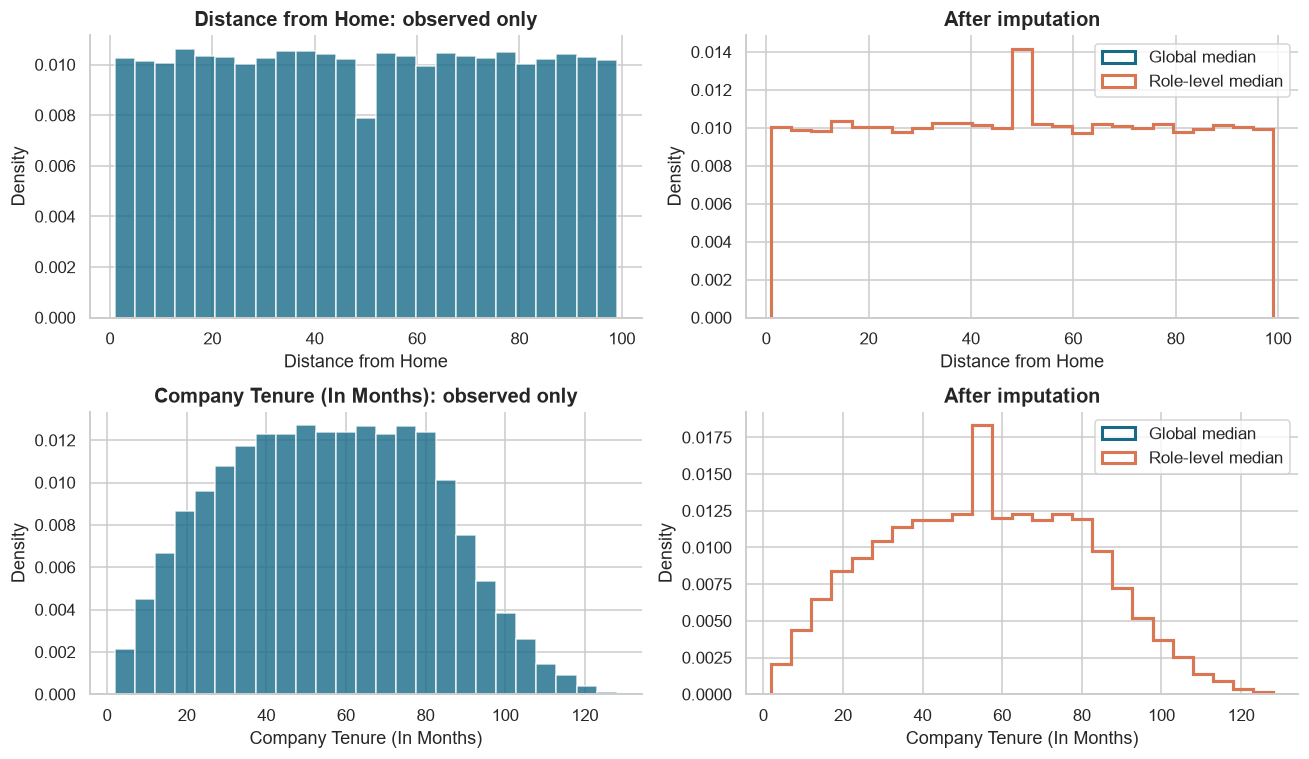

,scenario,rows,left_share_pct,income_mean,income_median,commute_median
0,Median / retain flags,74498,47.478,7344.875,7348.0,50.0
1,Role-level median,74498,47.478,7344.875,7348.0,50.0
2,Complete case,70558,47.885,7342.200,7353.0,50.0
3,Exclude early-start flags,56674,47.697,7343.598,7353.0,50.0
4,Income IQR capping,74498,47.478,7302.052,7348.0,50.0


In [3]:
group_clean = clean_data(raw,'group_median')
fig,axes = plt.subplots(2,2,figsize=(12,7))
for row,col in enumerate(MISSING):
    obs = raw.drop_duplicates()[col].dropna()
    bins = np.linspace(obs.min(),obs.max(),26)
    axes[row,0].hist(obs,bins=bins,density=True,color='#176B87',alpha=.8)
    axes[row,0].set_title(f'{col}: observed only')
    axes[row,1].hist(clean[col],bins=bins,density=True,histtype='step',linewidth=2,label='Global median')
    axes[row,1].hist(group_clean[col],bins=bins,density=True,histtype='step',linewidth=2,label='Role-level median')
    axes[row,1].set_title('After imputation'); axes[row,1].legend()
    for ax in axes[row]: ax.set_xlabel(col); ax.set_ylabel('Density')
finish('03_imputation_comparison')
display(pd.read_csv(ROOT/'Reports'/'scenario_summary.csv').round(3))

## Outliers using IQR, Z-score and boxplots

IQR fences are Q1 − 1.5×IQR and Q3 + 1.5×IQR. Z-score flags use |z| > 3 with population
standard deviation. Both are diagnostic tools, not proof of error. Z-scores are especially
awkward for bounded counts and skewed distributions: a legitimate promotion count can be flagged.
Income currency is unknown, so all figures use recorded units.

The income-capping scenario clips to IQR fences only for sensitivity analysis. The primary
cleaned dataset retains the original observed incomes.

,column,iqr_low,iqr_high,iqr_flagged,z_gt_3_flagged,policy
0,Age,-3.5,80.5,0,0,Flag and retain; no automatic deletion
1,Years at Company,-17.0,47.0,338,88,Flag and retain; no automatic deletion
2,Monthly Income,816.0,13712.0,151,90,Flag and retain; no automatic deletion
3,Number of Promotions,-3.0,5.0,0,989,Flag and retain; no automatic deletion
4,Distance from Home,-50.0,150.0,0,0,Flag and retain; no automatic deletion
5,Number of Dependents,-4.5,7.5,48,48,Flag and retain; no automatic deletion
6,Company Tenure (In Months),-24.0,136.0,0,0,Flag and retain; no automatic deletion


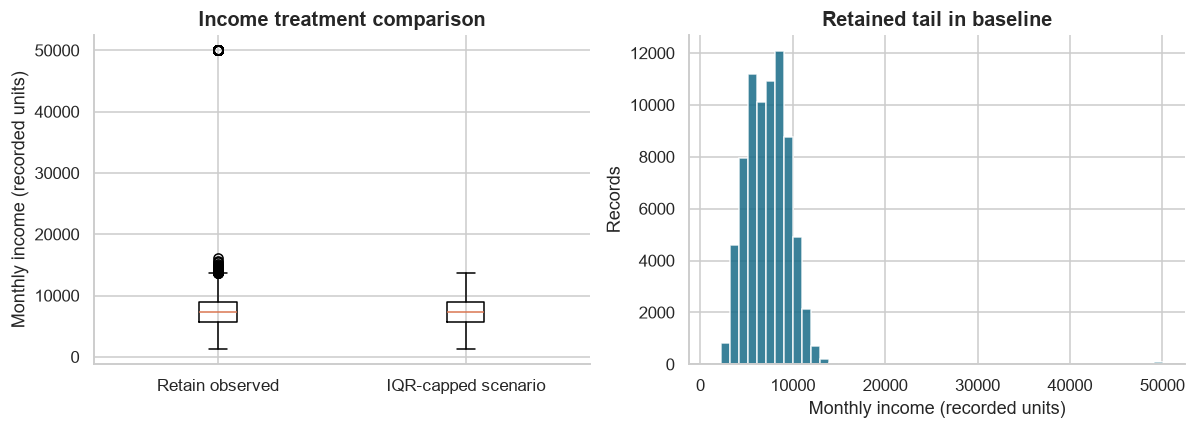

In [4]:
display(outlier_report(raw.drop_duplicates()).round(2))
variants = scenarios(raw)
fig,axes = plt.subplots(1,2,figsize=(11,4))
axes[0].boxplot([clean['Monthly Income'],variants['Income IQR capping']['Monthly Income']],
                tick_labels=['Retain observed','IQR-capped scenario'])
axes[0].set_ylabel('Monthly income (recorded units)'); axes[0].set_title('Income treatment comparison')
axes[1].hist(clean['Monthly Income'],bins=50,color='#176B87',alpha=.85)
axes[1].set_xlabel('Monthly income (recorded units)'); axes[1].set_ylabel('Records')
axes[1].set_title('Retained tail in baseline')
finish('03_income_outliers')

## Verify the cleaning contract

The checks below establish that row removal has a traceable reason, employee identifiers
remain unique, labels are unchanged, null handling is complete and imputation did not
overwrite observed numeric values. They do not resolve source-definition uncertainty.

In [5]:
dedup = raw.drop_duplicates().reset_index(drop=True)
assert len(clean) == len(dedup)
assert clean['Employee ID'].is_unique
assert clean['Attrition'].equals(dedup['Attrition'])
assert clean[MISSING].notna().all().all()
for col in MISSING:
    observed = dedup[col].notna()
    np.testing.assert_array_equal(clean.loc[observed,col],dedup.loc[observed,col])
np.testing.assert_array_equal(clean['Monthly Income'],dedup['Monthly Income'])
assert len(clean_data(raw,'complete_case')) == len(dedup.dropna(subset=MISSING))
print('Cleaning checks passed. Raw file remains unchanged.')

Cleaning checks passed. Raw file remains unchanged.


## Week 3 conclusion

The reproducible cleaned dataset and before/after reports are saved in `Dataset/Cleaned`
and `Reports`. Original fields remain readable; audit flags identify imputed and questionable
records. There is no scaling, label balancing or model training at this stage. When prediction
is introduced later, split data before fitting imputation, scaling or any resampling step.